In [1]:
import numpy as np
import mmcfilters
import matplotlib
import math

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16,16)

from IPython import display
from os import listdir
import cv2 as cv


In [ ]:
imgInput = cv.imread("../dat/lena.pgm", cv.IMREAD_GRAYSCALE)
#imgInput = cv.imread("../dat/imgTeste.png", cv.IMREAD_GRAYSCALE)

(num_rows, num_cols) = imgInput.shape

maxtree = mmcfilters.MorphologicalTree(imgInput, num_rows, num_cols, True, 1.5)
mintree = mmcfilters.MorphologicalTree(imgInput, num_rows, num_cols, False, 1.5)
tos4c8c = mmcfilters.MorphologicalTree(imgInput, num_rows, num_cols, ToSInperpolation="4c8c")
tos = mmcfilters.MorphologicalTree(imgInput, num_rows, num_cols, ToSInperpolation="self-dual")


filterMaxtree = mmcfilters.AttributeFilters(maxtree)
filterMintree = mmcfilters.AttributeFilters(mintree)
filterToS = mmcfilters.AttributeFilters(tos)
filterToS4c8c = mmcfilters.AttributeFilters(tos4c8c)

dic, attrs_maxtree = mmcfilters.Attribute.computerBasicAttributes(maxtree)
dic, attrs_mintree = mmcfilters.Attribute.computerBasicAttributes(mintree)
dic, attrs_tos = mmcfilters.Attribute.computerBasicAttributes(tos)
dic, attrs_tos4c8c = mmcfilters.Attribute.computerBasicAttributes(tos4c8c)
dic

In [ ]:

plt.subplot(1,5, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,5, 2)
plt.imshow(maxtree.reconstructionImage().reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('reconstruction (maxtree)')

plt.subplot(1,5, 3)
plt.imshow(mintree.reconstructionImage().reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('reconstruction (mintree)')

plt.subplot(1,5, 4)
plt.imshow(tos.reconstructionImage().reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('reconstruction (tos)')

plt.subplot(1,5, 5)
plt.imshow(tos4c8c.reconstructionImage().reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('reconstruction (tos4c8c)')

Text(0.5, 1.0, 'attribute filter (tos4c8c)')

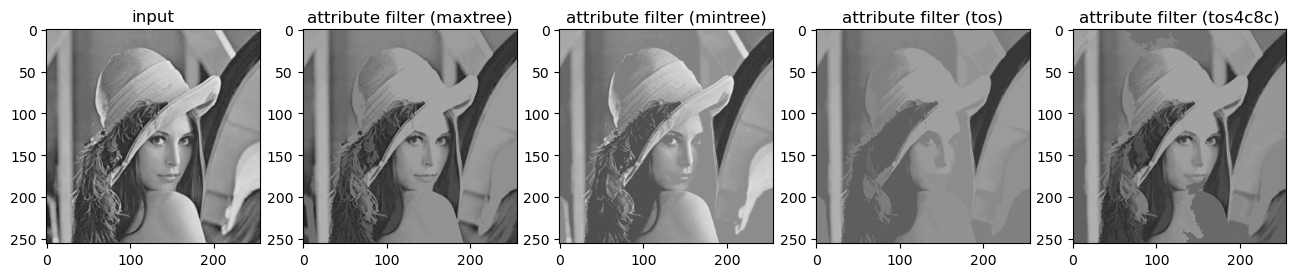

In [7]:
attr_type = dic['BOX_HEIGHT']
threshold = 150

att_maxtree = attrs_maxtree[:,attr_type]
att_mintree = attrs_mintree[:,attr_type]
att_tos = attrs_tos[:,attr_type]
att_tos4c8c = attrs_tos4c8c[:,attr_type]

imgFilteredMaxtree = filterMaxtree.filteringMax(att_maxtree > threshold)
imgFilteredMintree = filterMintree.filteringMax(att_mintree > threshold)
imgFilteredToS = filterToS.filteringMax(att_tos > threshold)
imgFilteredToS4c8c = filterToS4c8c.filteringMax(att_tos4c8c > threshold)

plt.subplot(1,5, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,5, 2)
plt.imshow(imgFilteredMaxtree.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (maxtree)')

plt.subplot(1,5, 3)
plt.imshow(imgFilteredMintree.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (mintree)')

plt.subplot(1,5, 4)
plt.imshow(imgFilteredToS.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (tos)')

plt.subplot(1,5, 5)
plt.imshow(imgFilteredToS4c8c.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (tos4c8c)')

In [54]:
from PrettyPrint import PrettyPrintTree
from colorama import Fore, Back
printTree = PrettyPrintTree(
    lambda node: node.children,
    lambda node: ("id:" + str(node.id) + " " + str(node.isMaxtree)[0], "level:" + str(node.level) + " (" + str(node.residue) + ")", "|cnps|:" + str(len(node.cnps))  ), 
#    lambda node: ("id:" + str(node.id) ), 
    color=Back.BLACK + Fore.WHITE
)

printTree(tos4c8c.root)

                                                                   ('id:0 F', 'level:0 (0)', '|cnps|:89121') 
                     ┌─────────────────────────────────────────────────────────────────┼─────────────────────────────────────────────────────────────────┐
 ('id:1 T', 'level:1 (1)', '|cnps|:24901')                         ('id:3 T', 'level:2 (2)', '|cnps|:71014')                         ('id:9 T', 'level:4 (4)', '|cnps|:15485') 
                     |                                           ┌─────────────────────┴─────────────────────┐                                                                 
  ('id:2 T', 'level:3 (2)', '|cnps|:8929')   ('id:4 T', 'level:5 (3)', '|cnps|:17592')   ('id:6 T', 'level:6 (4)', '|cnps|:13119')                                             
                                                                 |                                           |                                                                 
                               

In [56]:
printTree(tos.root)

                                                                      ('id:0 F', 'level:203 (203)', '|cnps|:89121') 
                      ┌─────────────────────────────────────────────────────────────────────┼──────────────────────────────────────────────────────────────────────┐
 ('id:1 F', 'level:126 (77)', '|cnps|:24901')                          ('id:3 F', 'level:78 (125)', '|cnps|:71014')                           ('id:9 F', 'level:54 (149)', '|cnps|:15485') 
                      |                                              ┌──────────────────────┴───────────────────────┐                                                                      
  ('id:2 F', 'level:72 (54)', '|cnps|:8929')    ('id:4 T', 'level:126 (48)', '|cnps|:17592')   ('id:6 T', 'level:161 (83)', '|cnps|:13119')                                                
                                                                     |                                              |                                     

In [58]:
att_tos

array([500., 200., 114., 478., 281.,  97., 175.,  68.,  23., 183.],
      dtype=float32)

In [68]:
att_tos4c8c

array([500., 200., 114., 478., 281.,  97., 175.,  68.,  23., 183.],
      dtype=float32)